In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "notebook_connected"

In [11]:
df = pd.read_parquet(r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\30_min\df_BA_TotActPwr_BESS_AC_Panel1.parquet")

print("Loaded dataframe shape:", df.shape)


Loaded dataframe shape: (9168, 195)


In [3]:
df.columns.tolist()

['BA_TotActPwr_BESS_AC_Panel1',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'PV_WS_Radiation_tplus_001',
 'PV_WS_Radiation_tplus_002',
 'PV_WS_Radiation_tplus_003',
 'PV_WS_Radiation_tplus_004',
 'PV_WS_Radiation_tplus_005',
 'PV_WS_Radiation_tplus_006',
 'PV_WS_Radiation_tplus_007',
 'PV_WS_Radiation_tplus_008',
 'PV_WS_Radiation_tplus_009',
 'PV_WS_Radiation_tplus_010',
 'PV_WS_Radiation_tplus_011',
 'PV_WS_Radiation_tplus_012',
 'PV_WS_Radiation_tplus_013',
 'PV_WS_Radiation_tplus_014',
 'PV_WS_Radiation_tplus_015',
 'PV_WS_Radiation_tplus_016',
 'PV_WS_Radiation_tplus_017',
 'PV_WS_Radiation_tplus_018',
 'PV_WS_Radiation_tplus_019',
 'PV_WS_Radiation_tplus_020',
 'PV_WS_Radiation_tplus_021',
 'PV_WS_Radiation_tplus_022',
 'PV_WS_Radiation_tplus_023',
 'PV_WS_Radiation_tplus_024',
 'PV_WS_Radiation_tplus_025',
 'PV_WS_Radiation_tplus_026',
 'PV_WS_Radiation_tplus_027',
 'PV_WS_Radiation_tplus_028',
 'PV_WS_Radiation_tplus_029',
 'PV_WS_Radiation_tplus_030',
 'PV_WS_Radiation_t

In [12]:
def plot_feature(df, cols=None, start=None, end=None, connectgaps=False):
    d = df.copy()

    # ensure datetime index
    d.index = pd.to_datetime(d.index, errors="coerce")
    d = d[~d.index.isna()].sort_index()

    # time filter
    if start is not None or end is not None:
        d = d.loc[start:end]

    # choose columns
    if cols is None:
        cols = d.columns.tolist()

    # numeric convert (important if some columns are strings)
    d[cols] = d[cols].apply(pd.to_numeric, errors="coerce")

    # plot multiple columns
    fig = px.line(d, x=d.index, y=cols,)
    fig.update_traces(connectgaps=connectgaps)
    fig.show()


In [13]:
plot_feature(df, cols=['BA_TotActPwr_BESS_AC_Panel1','BA_Soc'])

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [11]:
target_col = "BA_TotActPwr_BESS_AC_Panel1"
freq_per_day = 48                     # 96 for 15-min, 288 for 5-min, 24 for 60-min


df_work = df.copy()
df_work = df_work.sort_index()

# keep only target column
s = df_work[target_col].copy()

# create date and time slot
tmp = pd.DataFrame({target_col: s})
tmp["date"] = tmp.index.date
tmp["slot"] = tmp.index.hour * 60 + tmp.index.minute

# pivot: rows = days, columns = time slots
daily_profiles = tmp.pivot_table(
    index="date",
    columns="slot",
    values=target_col,
    aggfunc="mean"
)

# keep only complete days
daily_profiles = daily_profiles.dropna()

print("Daily profile shape:", daily_profiles.shape)
display(daily_profiles.head())

Daily profile shape: (191, 48)


slot,0,30,60,90,120,150,180,210,240,270,...,1140,1170,1200,1230,1260,1290,1320,1350,1380,1410
date,,,,,,,,,,,,,,,,,,,,,
2025-10-22,2.35433,2.45767,2.94617,2.81533,2.06333,2.01400,2.06000,2.06567,1.96817,2.20967,...,1.63500,1.63667,1.63600,1.63333,1.63483,1.62917,1.63183,1.63367,1.63217,2.23217
2025-10-23,1.99667,1.33667,1.33383,1.68433,2.07367,1.21017,1.09117,1.07800,1.04033,1.09683,...,1.34283,1.34283,1.34333,1.34417,1.52000,2.03350,1.39750,1.04983,1.19383,1.35167
2025-10-24,1.33967,1.36083,1.51400,1.59533,1.63650,1.53350,1.77450,1.68217,1.45250,1.77233,...,0.76000,0.76050,0.75933,0.75983,1.21900,1.47283,1.09117,1.02833,0.26900,0.36567
2025-10-25,0.58133,1.35433,1.96200,2.15833,1.96667,1.96633,0.88883,0.99967,1.38883,0.79717,...,3.23550,2.33017,1.33033,2.09767,3.63767,1.38783,0.45817,0.56333,1.32833,1.54450
2025-10-26,0.65933,1.29583,1.28400,1.92217,1.45567,0.80550,0.75600,0.70833,0.56033,1.00450,...,0.17033,0.17200,0.17217,0.17067,0.31483,0.70267,1.34933,2.06633,2.25933,2.42100


In [15]:
df[target_col].describe()
df[target_col].diff().abs().describe()

count    9167.000000
mean        0.495632
std         1.119353
min         0.000000
25%         0.001840
50%         0.053000
75%         0.526335
max        17.118000
Name: BA_TotActPwr_BESS_AC_Panel1, dtype: float64

In [16]:
df[target_col] = df[target_col].round(3)

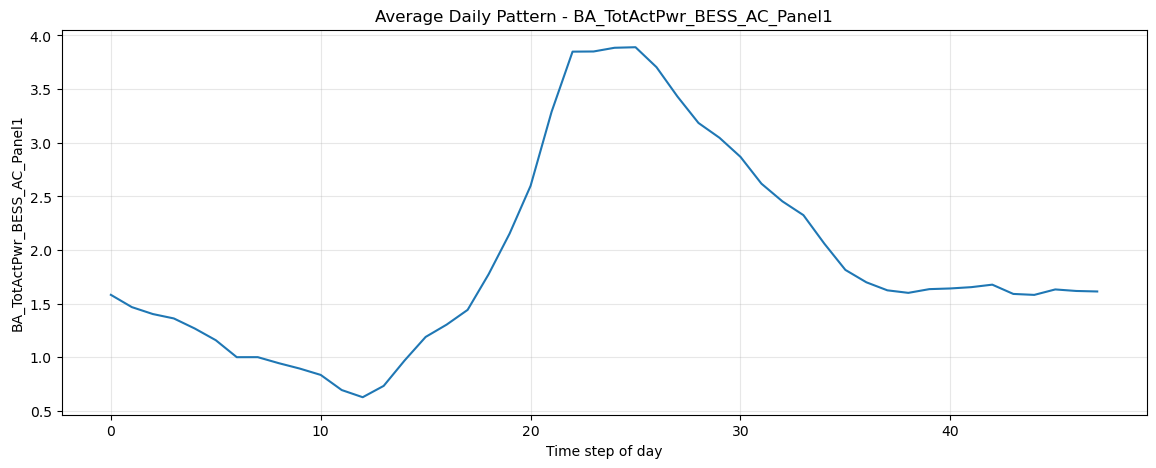

In [17]:
mean_profile = daily_profiles.mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(mean_profile.values)
plt.title(f"Average Daily Pattern - {target_col}")
plt.xlabel("Time step of day")
plt.ylabel(target_col)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
X = daily_profiles.values

# normalize shape, so clustering focuses on pattern shape
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = {}

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score

scores_df = pd.DataFrame({
    "n_clusters": list(scores.keys()),
    "silhouette_score": list(scores.values())
})

display(scores_df)

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarni

,n_clusters,silhouette_score
0,2,0.173698
1,3,0.173867
2,4,0.193351
3,5,0.170536
4,6,0.130622
5,7,0.134359


In [19]:
best_k = scores_df.sort_values("silhouette_score", ascending=False).iloc[0]["n_clusters"]
best_k = int(best_k)

print("Best number of clusters:", best_k)

Best number of clusters: 4


In [21]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
daily_profiles["pattern_cluster"] = kmeans.fit_predict(X_scaled)

cluster_counts = daily_profiles["pattern_cluster"].value_counts().sort_index()
display(cluster_counts)

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



pattern_cluster
0     4
1    35
2    53
3    99
Name: count, dtype: int64

In [22]:
most_common_cluster = cluster_counts.idxmax()
print("Most common daily pattern cluster:", most_common_cluster)
print("Number of days:", cluster_counts.loc[most_common_cluster])

Most common daily pattern cluster: 3
Number of days: 99


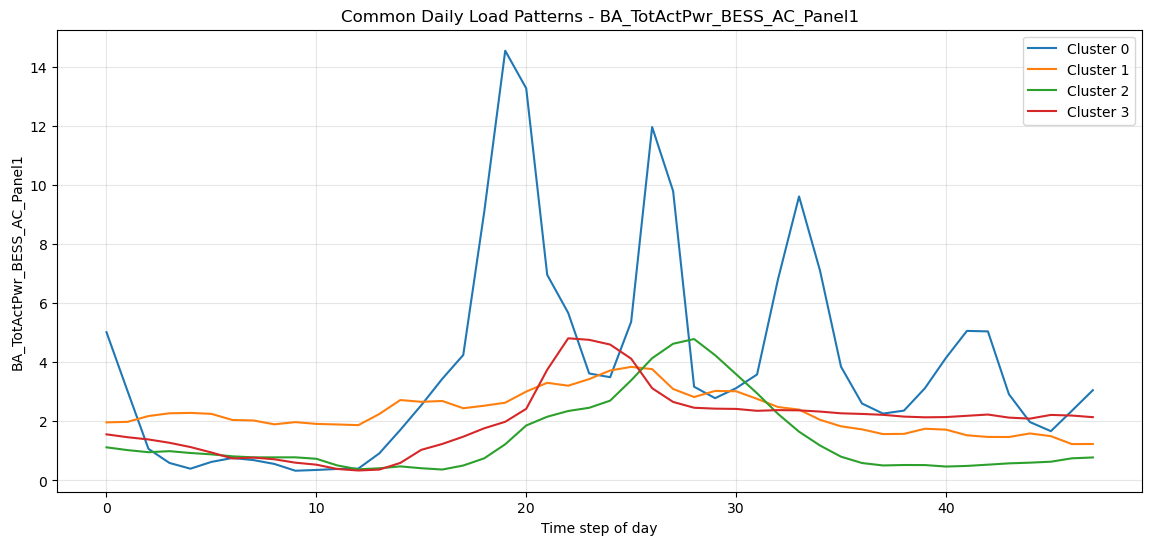

In [23]:
profile_cols = daily_profiles.columns.drop("pattern_cluster")

plt.figure(figsize=(14, 6))

for cluster_id in sorted(daily_profiles["pattern_cluster"].unique()):
    cluster_mean = daily_profiles[daily_profiles["pattern_cluster"] == cluster_id][profile_cols].mean(axis=0)
    plt.plot(cluster_mean.values, label=f"Cluster {cluster_id}")

plt.title(f"Common Daily Load Patterns - {target_col}")
plt.xlabel("Time step of day")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
common_days = daily_profiles[daily_profiles["pattern_cluster"] == most_common_cluster][profile_cols]

cluster_mean = common_days.mean(axis=0)

distances = ((common_days - cluster_mean) ** 2).sum(axis=1)
representative_day = distances.idxmin()

print("Representative day for most common pattern:", representative_day)

Representative day for most common pattern: 2026-01-22


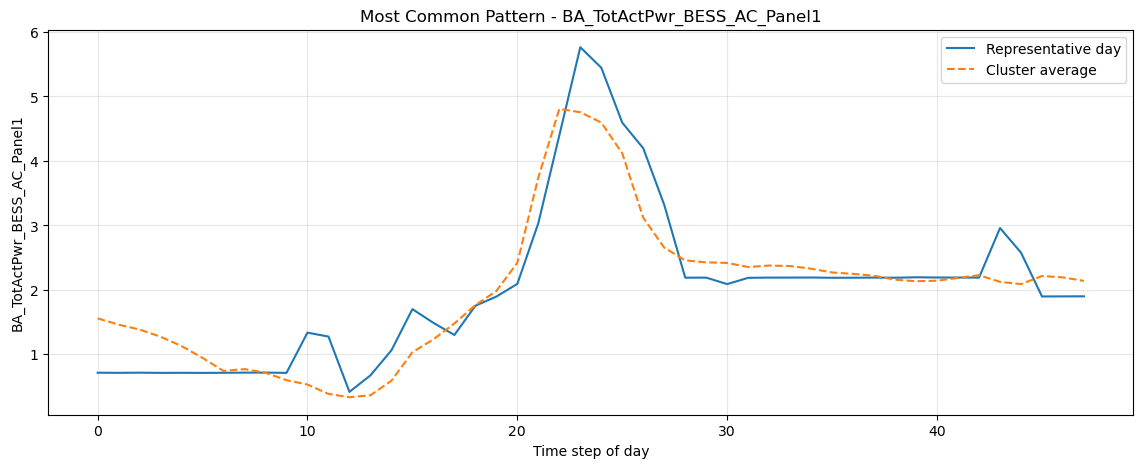

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(common_days.loc[representative_day].values, label="Representative day")
plt.plot(cluster_mean.values, label="Cluster average", linestyle="--")

plt.title(f"Most Common Pattern - {target_col}")
plt.xlabel("Time step of day")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
daily_info = pd.DataFrame(index=daily_profiles.index)
daily_info["date"] = pd.to_datetime(daily_info.index)
daily_info["dayofweek"] = daily_info["date"].dt.day_name()
daily_info["is_weekend"] = daily_info["date"].dt.dayofweek >= 5
daily_info["pattern_cluster"] = daily_profiles["pattern_cluster"].values

weekday_cluster_table = pd.crosstab(
    daily_info["dayofweek"],
    daily_info["pattern_cluster"],
    normalize="index"
) * 100

display(weekday_cluster_table.round(2))

pattern_cluster,0,1,2,3
dayofweek,,,,
Friday,3.70,25.93,22.22,48.15
Monday,0.00,14.81,29.63,55.56
Saturday,0.00,11.11,33.33,55.56
Sunday,0.00,3.70,33.33,62.96
Thursday,3.57,25.00,28.57,42.86
Tuesday,3.70,25.93,22.22,48.15
Wednesday,3.57,21.43,25.00,50.00


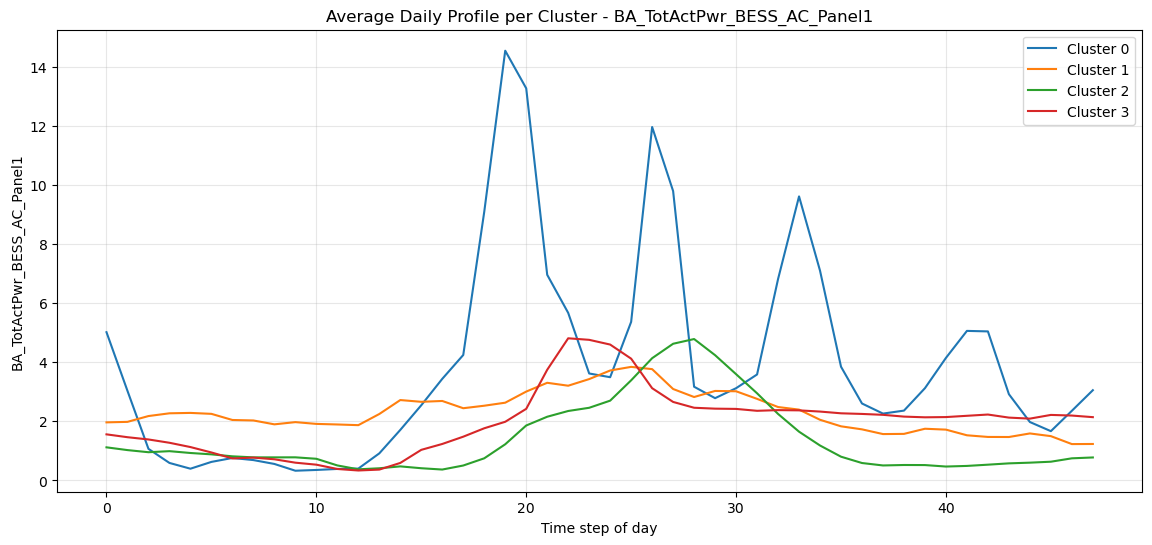

In [27]:
profile_cols = daily_profiles.columns.drop("pattern_cluster")

plt.figure(figsize=(14, 6))

for cluster_id in sorted(daily_profiles["pattern_cluster"].unique()):
    cluster_mean = daily_profiles[daily_profiles["pattern_cluster"] == cluster_id][profile_cols].mean(axis=0)
    plt.plot(cluster_mean.values, label=f"Cluster {cluster_id}")

plt.title(f"Average Daily Profile per Cluster - {target_col}")
plt.xlabel("Time step of day")
plt.ylabel(target_col)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
# import pandas as pd
# import numpy as np

# target_col = "BA_TotActPwr_BESS_AC_Panel2"

# feature_cols = [c for c in df.columns if c != target_col]
# # keep only columns that exist in dataframe
# feature_cols = [c for c in feature_cols if c in df.columns]

# corr_rows = []

# for col in feature_cols:
#     temp = df[[target_col, col]].dropna()

#     if len(temp) < 10:
#         continue

#     pearson_corr = temp[target_col].corr(temp[col], method="pearson")
#     spearman_corr = temp[target_col].corr(temp[col], method="spearman")

#     corr_rows.append({
#         "feature": col,
#         "pearson_corr": pearson_corr,
#         "spearman_corr": spearman_corr,
#         "abs_pearson": abs(pearson_corr),
#         "abs_spearman": abs(spearman_corr),
#         "n_samples": len(temp)
#     })

# corr_df = pd.DataFrame(corr_rows)

# corr_df = corr_df.sort_values("abs_pearson", ascending=False)

# corr_df.head(30)

    pearson_corr  → linear relation
    spearman_corr → monotonic/nonlinear rank relation
    abs_pearson   → strength, ignoring sign

In [14]:
corr_df[[
    "feature",
    "pearson_corr",
    "spearman_corr",
    "abs_pearson",
    "abs_spearman",
    "n_samples"
]].head(40)

,feature,pearson_corr,spearman_corr,abs_pearson,abs_spearman,n_samples
143,BA_TotActPwr_BESS_AC_Panel2_dev_from_rolling_7...,0.981643,0.924212,0.981643,0.924212,18336
142,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_week...,0.981643,0.924212,0.981643,0.924212,18336
141,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_day_...,0.954762,0.861252,0.954762,0.861252,18336
81,BA_TotActPwr_BESS_AC_Panel2_ramp_up_roll_mean_4,0.677292,0.438839,0.677292,0.438839,18336
80,BA_TotActPwr_BESS_AC_Panel2_ramp_up_roll_sum_4,0.677292,0.438839,0.677292,0.438839,18336
145,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_week...,0.634712,0.552630,0.634712,0.552630,18336
144,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_day_...,0.593454,0.496598,0.593454,0.496598,18336
57,BA_TotActPwr_BESS_AC_Panel2_abs_diff_4,0.579445,0.366474,0.579445,0.366474,18336
56,BA_TotActPwr_BESS_AC_Panel2_diff_4,0.563107,0.384698,0.563107,0.384698,18336
55,BA_TotActPwr_BESS_AC_Panel2_abs_diff_2,0.514722,0.371611,0.514722,0.371611,18336


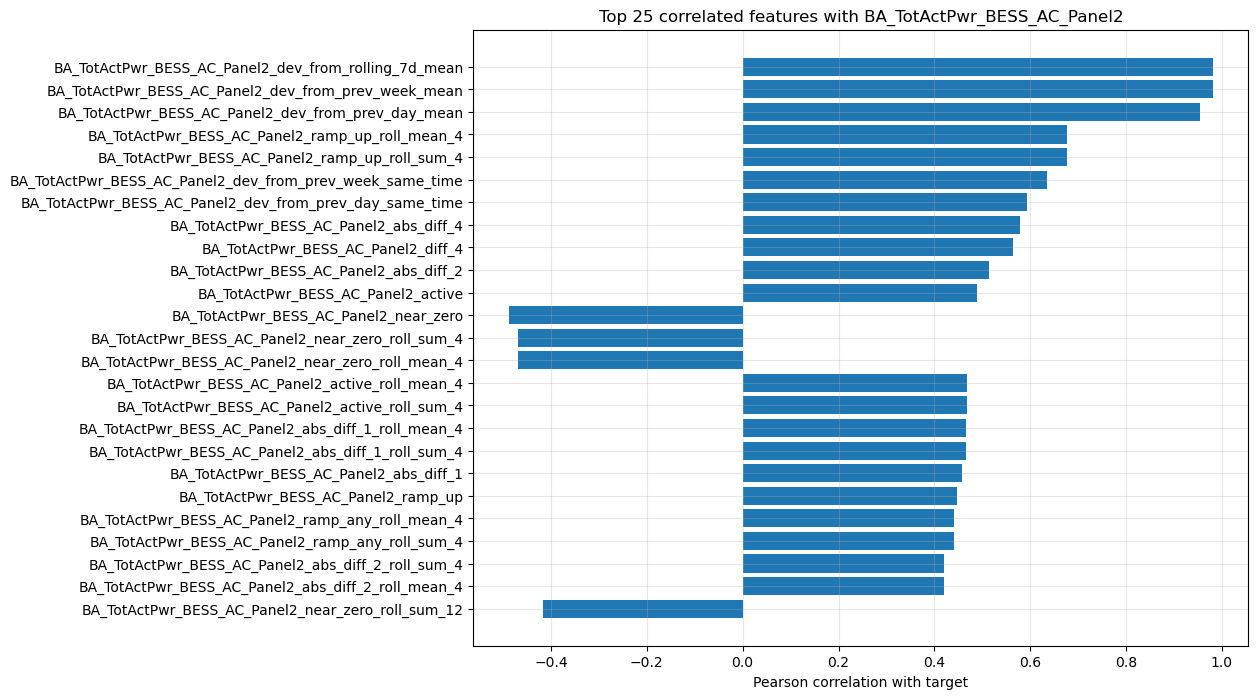

In [15]:
import matplotlib.pyplot as plt

top_n = 25

top_corr = corr_df.head(top_n).sort_values("abs_pearson")

plt.figure(figsize=(10, 8))
plt.barh(top_corr["feature"], top_corr["pearson_corr"])
plt.xlabel("Pearson correlation with target")
plt.title(f"Top {top_n} correlated features with {target_col}")
plt.grid(True, alpha=0.3)
plt.show()

### Check correlation only during active battery periods

In [16]:
active_threshold = 0.5

df_active = df[df[target_col].abs() > active_threshold].copy()

active_corr_rows = []

for col in feature_cols:
    temp = df_active[[target_col, col]].dropna()

    if len(temp) < 10:
        continue

    pearson_corr = temp[target_col].corr(temp[col], method="pearson")
    spearman_corr = temp[target_col].corr(temp[col], method="spearman")

    active_corr_rows.append({
        "feature": col,
        "active_pearson_corr": pearson_corr,
        "active_spearman_corr": spearman_corr,
        "active_abs_pearson": abs(pearson_corr),
        "active_abs_spearman": abs(spearman_corr),
        "active_n_samples": len(temp)
    })

active_corr_df = pd.DataFrame(active_corr_rows)
active_corr_df = active_corr_df.sort_values("active_abs_pearson", ascending=False)

active_corr_df.head(30)

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

c:\Users\MAVANI\AppData\Local\miniconda3\envs\lf\Lib\site-packages\pandas\core\nanops.py:1661: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



,feature,active_pearson_corr,active_spearman_corr,active_abs_pearson,active_abs_spearman,active_n_samples
143,BA_TotActPwr_BESS_AC_Panel2_dev_from_rolling_7...,0.981065,0.871069,0.981065,0.871069,14043
142,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_week...,0.981065,0.871069,0.981065,0.871069,14043
141,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_day_...,0.958825,0.792510,0.958825,0.792510,14043
80,BA_TotActPwr_BESS_AC_Panel2_ramp_up_roll_sum_4,0.691474,0.456052,0.691474,0.456052,14043
81,BA_TotActPwr_BESS_AC_Panel2_ramp_up_roll_mean_4,0.691474,0.456052,0.691474,0.456052,14043
145,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_week...,0.632379,0.483101,0.632379,0.483101,14043
56,BA_TotActPwr_BESS_AC_Panel2_diff_4,0.616627,0.414487,0.616627,0.414487,14043
57,BA_TotActPwr_BESS_AC_Panel2_abs_diff_4,0.607043,0.230464,0.607043,0.230464,14043
144,BA_TotActPwr_BESS_AC_Panel2_dev_from_prev_day_...,0.590722,0.441043,0.590722,0.441043,14043
55,BA_TotActPwr_BESS_AC_Panel2_abs_diff_2,0.515771,0.203591,0.515771,0.203591,14043


### Compare all-period vs active-period correlation

In [17]:
corr_compare = corr_df.merge(
    active_corr_df,
    on="feature",
    how="left"
)

corr_compare[[
    "feature",
    "pearson_corr",
    "active_pearson_corr",
    "spearman_corr",
    "active_spearman_corr",
    "n_samples",
    "active_n_samples"
]].sort_values("active_abs_pearson", ascending=False).head(40)

KeyError: 'active_abs_pearson'

### Check correlation with target absolute power

In [78]:
df["target_abs_power"] = df[target_col].abs()

abs_corr_rows = []

for col in feature_cols:
    temp = df[["target_abs_power", col]].dropna()

    if len(temp) < 10:
        continue

    pearson_corr = temp["target_abs_power"].corr(temp[col], method="pearson")
    spearman_corr = temp["target_abs_power"].corr(temp[col], method="spearman")

    abs_corr_rows.append({
        "feature": col,
        "abs_target_pearson_corr": pearson_corr,
        "abs_target_spearman_corr": spearman_corr,
        "abs_corr_strength": abs(pearson_corr),
        "n_samples": len(temp)
    })

abs_target_corr_df = pd.DataFrame(abs_corr_rows)
abs_target_corr_df = abs_target_corr_df.sort_values("abs_corr_strength", ascending=False)

abs_target_corr_df.head(30)

,feature,abs_target_pearson_corr,abs_target_spearman_corr,abs_corr_strength,n_samples
12,BA_TotActPwr_BESS_AC_Panel2_lag_1,0.889039,0.926141,0.889039,17109
13,BA_TotActPwr_BESS_AC_Panel2_lag_2,0.710110,0.849563,0.710110,17098
24,BA_TotActPwr_BESS_AC_Panel2_roll_mean_4,0.685168,0.831099,0.685168,17049
35,BA_TotActPwr_BESS_AC_Panel2_trend_1_12,0.560807,0.509790,0.560807,17000
34,BA_TotActPwr_BESS_AC_Panel2_trend_1_4,0.533581,0.356188,0.533581,17065
14,BA_TotActPwr_BESS_AC_Panel2_lag_3,0.524439,0.771353,0.524439,17087
36,BA_TotActPwr_BESS_AC_Panel2_trend_1_96,0.492687,0.448730,0.492687,16591
25,BA_TotActPwr_BESS_AC_Panel2_roll_mean_12,0.469585,0.616073,0.469585,16893
1,PV_WS_AirTemp,0.409533,0.426580,0.409533,16674
2,PV_WS_Radiation,0.393186,0.334238,0.393186,16673


### Use mutual information for nonlinear pattern detection

In [79]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
import pandas as pd

mi_cols = [c for c in feature_cols if c in df.columns]

data_mi = df[[target_col] + mi_cols].copy()
data_mi = data_mi.dropna(subset=[target_col])

X = data_mi[mi_cols]
y = data_mi[target_col]

imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(X)

mi_scores = mutual_info_regression(
    X_imp,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": mi_cols,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

mi_df.head(30)

,feature,mutual_information
12,BA_TotActPwr_BESS_AC_Panel2_lag_1,1.586270
13,BA_TotActPwr_BESS_AC_Panel2_lag_2,1.248051
24,BA_TotActPwr_BESS_AC_Panel2_roll_mean_4,1.206122
14,BA_TotActPwr_BESS_AC_Panel2_lag_3,1.046572
15,BA_TotActPwr_BESS_AC_Panel2_lag_4,0.912585
25,BA_TotActPwr_BESS_AC_Panel2_roll_mean_12,0.759087
16,BA_TotActPwr_BESS_AC_Panel2_lag_8,0.646732
36,BA_TotActPwr_BESS_AC_Panel2_trend_1_96,0.641640
35,BA_TotActPwr_BESS_AC_Panel2_trend_1_12,0.516573
33,BA_TotActPwr_BESS_AC_Panel2_roll_std_96,0.506527


### Final combined feature relevance table

In [80]:
feature_relevance = corr_df.merge(
    active_corr_df,
    on="feature",
    how="left"
).merge(
    abs_target_corr_df[["feature", "abs_target_pearson_corr", "abs_target_spearman_corr"]],
    on="feature",
    how="left"
).merge(
    mi_df,
    on="feature",
    how="left"
)

feature_relevance = feature_relevance.sort_values(
    ["mutual_information", "abs_pearson"],
    ascending=False
)

feature_relevance.head(40)

,feature,pearson_corr,spearman_corr,abs_pearson,abs_spearman,n_samples,active_pearson_corr,active_spearman_corr,active_abs_pearson,active_abs_spearman,active_n_samples,abs_target_pearson_corr,abs_target_spearman_corr,mutual_information
0,BA_TotActPwr_BESS_AC_Panel2_lag_1,0.889039,0.926141,0.889039,0.926141,17109,0.855025,0.859203,0.855025,0.859203,12524,0.889039,0.926141,1.586270
1,BA_TotActPwr_BESS_AC_Panel2_lag_2,0.710110,0.849563,0.710110,0.849563,17098,0.628516,0.723931,0.628516,0.723931,12515,0.710110,0.849563,1.248051
2,BA_TotActPwr_BESS_AC_Panel2_roll_mean_4,0.685168,0.831099,0.685168,0.831099,17049,0.590619,0.694401,0.590619,0.694401,12476,0.685168,0.831099,1.206122
5,BA_TotActPwr_BESS_AC_Panel2_lag_3,0.524439,0.771353,0.524439,0.771353,17087,0.397822,0.600834,0.397822,0.600834,12506,0.524439,0.771353,1.046572
10,BA_TotActPwr_BESS_AC_Panel2_lag_4,0.368161,0.695198,0.368161,0.695198,17077,0.214777,0.494680,0.214777,0.494680,12498,0.368161,0.695198,0.912585
7,BA_TotActPwr_BESS_AC_Panel2_roll_mean_12,0.469585,0.616073,0.469585,0.616073,16893,0.336290,0.430836,0.336290,0.430836,12352,0.469585,0.616073,0.759087
26,BA_TotActPwr_BESS_AC_Panel2_lag_8,0.168935,0.489315,0.168935,0.489315,17044,0.040805,0.278466,0.040805,0.278466,12473,0.168935,0.489315,0.646732
6,BA_TotActPwr_BESS_AC_Panel2_trend_1_96,0.492687,0.448730,0.492687,0.448730,16591,0.476525,0.392736,0.476525,0.392736,12210,0.492687,0.448730,0.641640
3,BA_TotActPwr_BESS_AC_Panel2_trend_1_12,0.560807,0.509790,0.560807,0.509790,17000,0.582388,0.495213,0.582388,0.495213,12440,0.560807,0.509790,0.516573
28,BA_TotActPwr_BESS_AC_Panel2_roll_std_96,0.146508,0.063899,0.146508,0.063899,15451,0.174962,0.179961,0.174962,0.179961,11427,0.146508,0.063899,0.506527


In [102]:
import importlib
import src.profile_trainer as profile_trainer

importlib.reload(profile_trainer)

from src.profile_trainer import run_profile_training_experiment

print(inspect.signature(run_profile_training_experiment))

(df: 'pd.DataFrame', *, target_col: 'str', feature_cols: 'list[str]', dataset_name: 'str', feature_set_name: 'str' = 'default_features', horizon_steps: 'int' = 96, issue_hour: 'int' = 23, issue_minute: 'int' = 45, train_ratio: 'float' = 0.7, val_ratio: 'float' = 0.15, test_ratio: 'float' = 0.15, selected_models: 'list[str] | None' = None, drop_feature_nan: 'bool' = False, data_mode: 'str' = 'auto') -> 'tuple[pd.DataFrame, dict[str, pd.DataFrame]]'


In [103]:
target_col = "BA_TotActPwr_BESS_AC_Panel2"

# Make sure index is datetime
df = df.copy()
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].sort_index()

# Remove duplicate timestamps if any
df = df[~df.index.duplicated(keep="first")]

print(df.shape)
print(df.index.min(), df.index.max())

(19008, 106)
2025-10-15 00:00:00 2026-04-30 23:45:00


In [104]:
p = df[target_col]

# Change / ramp magnitude
df[f"{target_col}_diff_1"] = p.diff(1)
df[f"{target_col}_diff_2"] = p.diff(2)
df[f"{target_col}_diff_4"] = p.diff(4)

df[f"{target_col}_abs_diff_1"] = p.diff(1).abs()
df[f"{target_col}_abs_diff_2"] = p.diff(2).abs()
df[f"{target_col}_abs_diff_4"] = p.diff(4).abs()

# Operating state at current timestamp
active_threshold = 0.5

df[f"{target_col}_active"] = (p.abs() > active_threshold).astype(int)
df[f"{target_col}_near_zero"] = (p.abs() <= active_threshold).astype(int)

# Ramp flags
ramp_threshold = 1.0

df[f"{target_col}_ramp_up"] = (p.diff(1) > ramp_threshold).astype(int)
df[f"{target_col}_ramp_down"] = (p.diff(1) < -ramp_threshold).astype(int)

In [105]:
pattern_base_cols = [
    f"{target_col}_active",
    f"{target_col}_near_zero",
    f"{target_col}_ramp_up",
    f"{target_col}_ramp_down",
    f"{target_col}_abs_diff_1",
    f"{target_col}_abs_diff_2",
    f"{target_col}_abs_diff_4",
]

rolling_windows = [4, 12, 24, 96]

for col in pattern_base_cols:
    for win in rolling_windows:
        df[f"{col}_roll_sum_{win}"] = df[col].shift(1).rolling(win).sum()
        df[f"{col}_roll_mean_{win}"] = df[col].shift(1).rolling(win).mean()

In [106]:
calendar_features = [
    "dayofweek",
    "is_weekend",
    "hour",
    "sin_tod",
    "cos_tod",
    "sin_dow",
    "cos_dow",
    "is_midday_peak_window",
    "is_midday_weekday_peak",
]

external_features = [
    "BA_Soc",
    "PV_WS_AirTemp",
    "PV_WS_Radiation",
]

lag_features = [
    f"{target_col}_lag_1",
    f"{target_col}_lag_2",
    f"{target_col}_lag_3",
    f"{target_col}_lag_4",
    f"{target_col}_lag_8",
    f"{target_col}_lag_12",
    f"{target_col}_lag_24",
    f"{target_col}_lag_48",
    f"{target_col}_lag_96",
    f"{target_col}_lag_192",
    f"{target_col}_lag_288",
]

rolling_features = [
    f"{target_col}_roll_mean_4",
    f"{target_col}_roll_mean_12",
    f"{target_col}_roll_mean_24",
    f"{target_col}_roll_mean_48",
    f"{target_col}_roll_mean_96",
    f"{target_col}_roll_mean_288",
    f"{target_col}_roll_std_12",
    f"{target_col}_roll_std_24",
    f"{target_col}_roll_std_48",
    f"{target_col}_roll_std_96",
]

trend_features = [
    f"{target_col}_trend_1_4",
    f"{target_col}_trend_1_12",
    f"{target_col}_trend_1_96",
    f"{target_col}_trend_96_192",
]

extra_pattern_features = [
    f"{target_col}_diff_1",
    f"{target_col}_diff_2",
    f"{target_col}_diff_4",
    f"{target_col}_abs_diff_1",
    f"{target_col}_abs_diff_2",
    f"{target_col}_abs_diff_4",
    f"{target_col}_active",
    f"{target_col}_near_zero",
    f"{target_col}_ramp_up",
    f"{target_col}_ramp_down",
]

# Add rolling pattern feature names
for col in pattern_base_cols:
    for win in rolling_windows:
        extra_pattern_features.append(f"{col}_roll_sum_{win}")
        extra_pattern_features.append(f"{col}_roll_mean_{win}")

In [107]:
profile_feature_cols = (
    calendar_features
    + external_features
    + lag_features
    + rolling_features
    + trend_features
    + extra_pattern_features
)

# Keep only columns that exist in df
profile_feature_cols = [c for c in profile_feature_cols if c in df.columns]

# Very important: remove target itself if accidentally included
profile_feature_cols = [c for c in profile_feature_cols if c != target_col]

print("Number of features:", len(profile_feature_cols))
profile_feature_cols

Number of features: 103


['dayofweek',
 'is_weekend',
 'hour',
 'sin_tod',
 'cos_tod',
 'sin_dow',
 'cos_dow',
 'is_midday_peak_window',
 'is_midday_weekday_peak',
 'BA_Soc',
 'PV_WS_AirTemp',
 'PV_WS_Radiation',
 'BA_TotActPwr_BESS_AC_Panel2_lag_1',
 'BA_TotActPwr_BESS_AC_Panel2_lag_2',
 'BA_TotActPwr_BESS_AC_Panel2_lag_3',
 'BA_TotActPwr_BESS_AC_Panel2_lag_4',
 'BA_TotActPwr_BESS_AC_Panel2_lag_8',
 'BA_TotActPwr_BESS_AC_Panel2_lag_12',
 'BA_TotActPwr_BESS_AC_Panel2_lag_24',
 'BA_TotActPwr_BESS_AC_Panel2_lag_48',
 'BA_TotActPwr_BESS_AC_Panel2_lag_96',
 'BA_TotActPwr_BESS_AC_Panel2_lag_192',
 'BA_TotActPwr_BESS_AC_Panel2_lag_288',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_4',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_12',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_24',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_48',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_96',
 'BA_TotActPwr_BESS_AC_Panel2_roll_mean_288',
 'BA_TotActPwr_BESS_AC_Panel2_roll_std_12',
 'BA_TotActPwr_BESS_AC_Panel2_roll_std_24',
 'BA_TotActPwr_BESS_AC_Panel

In [ ]:
issue_hour = 23
issue_minute = 45

issue_mask = (
    (df.index.hour == issue_hour) &
    (df.index.minute == issue_minute)
)

df_issue = df.loc[issue_mask, profile_feature_cols + [target_col]].copy()

missing_issue = (
    df_issue[profile_feature_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)#
    .to_frame("missing_ratio")
)

missing_issue.head(30)

,missing_ratio
BA_TotActPwr_BESS_AC_Panel2_roll_mean_288,0.323232
BA_TotActPwr_BESS_AC_Panel2_abs_diff_4_roll_mean_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_abs_diff_4_roll_sum_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_abs_diff_1_roll_sum_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_abs_diff_1_roll_mean_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_abs_diff_2_roll_sum_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_abs_diff_2_roll_mean_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_roll_std_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_roll_mean_96,0.191919
BA_TotActPwr_BESS_AC_Panel2_roll_mean_48,0.171717


In [109]:
feature_sets = {
    "calendar_only": [
        c for c in calendar_features
        if c in df.columns
    ],

    "external_calendar": [
        c for c in calendar_features + external_features
        if c in df.columns
    ],

    "autoregressive_pattern": [
        c for c in lag_features + rolling_features + trend_features + extra_pattern_features
        if c in df.columns
    ],

    "full_model": profile_feature_cols,
}

# Remove target from every feature set
for name in feature_sets:
    feature_sets[name] = [c for c in feature_sets[name] if c != target_col]
    print(name, len(feature_sets[name]))

calendar_only 9
external_calendar 12
autoregressive_pattern 91
full_model 103


In [114]:
all_results = []
all_horizon_results = {}

for feature_set_name, feature_cols in feature_sets.items():

    print("\n==============================")
    print("Running:", feature_set_name)
    print("Number of features:", len(feature_cols))
    print("==============================")

    results_df, horizon_results = run_profile_training_experiment(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols,
        dataset_name=f"bess_panel2_day_ahead_{feature_set_name}",
        feature_set_name=feature_set_name,
        horizon_steps=96,
        issue_hour=23,
        issue_minute=45,
        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        selected_models=[
            "ridge",
            "random_forest",
            "xgboost",
        ],
        drop_feature_nan=False,
        data_mode="auto",
    )

    results_df["feature_set"] = feature_set_name
    all_results.append(results_df)

    for model_name, hdf in horizon_results.items():
        all_horizon_results[(feature_set_name, model_name)] = hdf


Running: calendar_only
Number of features: 9
Training ridge for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [dense]
Training random_forest for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [dense]
Training xgboost for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [dense]

Running: external_calendar
Number of features: 12
Training xgboost for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [NaNs]

Running: autoregressive_pattern
Number of features: 91
Training xgboost for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [NaNs]

Running: full_model
Number of features: 103
Training xgboost for day-ahead profile forecasting: BA_TotActPwr_BESS_AC_Panel2 [NaNs]


In [115]:
profile_results_compare = pd.concat(all_results, ignore_index=True)

cols_to_show = [
    "feature_set",
    "model_name",
    "n_features",
    "n_train_days",
    "n_val_days",
    "n_test_days",
    "test_MAE",
    "test_RMSE",
    "test_MAPE",
    "test_sMAPE",
    "test_R2",
]

profile_results_compare[cols_to_show].sort_values("test_RMSE")

,feature_set,model_name,n_features,n_train_days,n_val_days,n_test_days,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2
0,calendar_only,ridge,9,112,24,24,1.407688,2.216709,312.065931,75.339049,0.074365
2,calendar_only,xgboost,9,112,24,24,1.431830,2.242816,308.528652,76.465747,0.052434
1,calendar_only,random_forest,9,112,24,24,1.431878,2.243016,308.121050,76.452027,0.052265
3,external_calendar,xgboost,12,112,24,24,1.446298,2.265030,271.273697,79.630321,0.033570
5,full_model,xgboost,103,112,24,24,1.482128,2.297857,339.036133,73.549528,0.005355
4,autoregressive_pattern,xgboost,91,112,24,24,1.547983,2.390966,363.703095,73.989796,-0.076884


In [116]:
display_cols = [
    c for c in [
        "feature_set",
        "model_name",
        "n_features",
        "n_train_days",
        "n_val_days",
        "n_test_days",
        "test_MAE",
        "test_RMSE",
        "test_MAPE",
        "test_sMAPE",
        "test_R2",
        "prediction_path",
        "horizon_metrics_path",
    ]
    if c in profile_results_compare.columns
]

profile_results_compare[display_cols].sort_values("test_RMSE")

,feature_set,model_name,n_features,n_train_days,n_val_days,n_test_days,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,prediction_path,horizon_metrics_path
0,calendar_only,ridge,9,112,24,24,1.407688,2.216709,312.065931,75.339049,0.074365,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,calendar_only,xgboost,9,112,24,24,1.431830,2.242816,308.528652,76.465747,0.052434,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,calendar_only,random_forest,9,112,24,24,1.431878,2.243016,308.121050,76.452027,0.052265,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,external_calendar,xgboost,12,112,24,24,1.446298,2.265030,271.273697,79.630321,0.033570,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
5,full_model,xgboost,103,112,24,24,1.482128,2.297857,339.036133,73.549528,0.005355,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,autoregressive_pattern,xgboost,91,112,24,24,1.547983,2.390966,363.703095,73.989796,-0.076884,C:\Data_analysis\Thesis\outputs\profile_foreca...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [112]:
import inspect
from src.profile_trainer import run_profile_training_experiment

print(inspect.getsourcefile(run_profile_training_experiment))
print(inspect.signature(run_profile_training_experiment))

c:\Data_analysis\Thesis\src\profile_trainer.py
(df: 'pd.DataFrame', *, target_col: 'str', feature_cols: 'list[str]', dataset_name: 'str', feature_set_name: 'str' = 'default_features', horizon_steps: 'int' = 96, issue_hour: 'int' = 23, issue_minute: 'int' = 45, train_ratio: 'float' = 0.7, val_ratio: 'float' = 0.15, test_ratio: 'float' = 0.15, selected_models: 'list[str] | None' = None, drop_feature_nan: 'bool' = False, data_mode: 'str' = 'auto') -> 'tuple[pd.DataFrame, dict[str, pd.DataFrame]]'


In [101]:
import inspect
from src.profile_trainer import run_profile_training_experiment

print(inspect.signature(run_profile_training_experiment))

(df: 'pd.DataFrame', *, target_col: 'str', feature_cols: 'list[str]', dataset_name: 'str', feature_set_name: 'str' = 'default_features', horizon_steps: 'int' = 96, issue_hour: 'int' = 23, issue_minute: 'int' = 45, train_ratio: 'float' = 0.7, val_ratio: 'float' = 0.15, test_ratio: 'float' = 0.15, selected_models: 'list[str] | None' = None, drop_feature_nan: 'bool' = False, data_mode: 'str' = 'auto') -> 'tuple[pd.DataFrame, dict[str, pd.DataFrame]]'


In [ ]:
target_col = "BA_TotActPwr_BESS_AC_Panel2"

profile_feature_cols = [
    # current/known system state at issue time
    "BA_Soc",
    "PV_WS_AirTemp",
    "PV_WS_Radiation",

    # calendar features
    "dayofweek",
    "is_weekend",
    "hour",
    "sin_tod",
    "cos_tod",
    "sin_dow",
    "cos_dow",
    "is_midday_peak_window",
    "is_midday_weekday_peak",

    # autoregressive memory
    "BA_TotActPwr_BESS_AC_Panel2_lag_1",
    "BA_TotActPwr_BESS_AC_Panel2_lag_2",
    "BA_TotActPwr_BESS_AC_Panel2_lag_3",
    "BA_TotActPwr_BESS_AC_Panel2_lag_4",
    "BA_TotActPwr_BESS_AC_Panel2_lag_8",
    "BA_TotActPwr_BESS_AC_Panel2_lag_12",
    "BA_TotActPwr_BESS_AC_Panel2_lag_24",
    "BA_TotActPwr_BESS_AC_Panel2_lag_96",
    "BA_TotActPwr_BESS_AC_Panel2_lag_192",
    "BA_TotActPwr_BESS_AC_Panel2_lag_288",

    # short-term level
    "BA_TotActPwr_BESS_AC_Panel2_roll_mean_4",
    "BA_TotActPwr_BESS_AC_Panel2_roll_mean_12",
    "BA_TotActPwr_BESS_AC_Panel2_roll_mean_24",
    "BA_TotActPwr_BESS_AC_Panel2_roll_mean_96",
    "BA_TotActPwr_BESS_AC_Panel2_roll_mean_288",

    # volatility
    "BA_TotActPwr_BESS_AC_Panel2_roll_std_12",
    "BA_TotActPwr_BESS_AC_Panel2_roll_std_24",
    "BA_TotActPwr_BESS_AC_Panel2_roll_std_96",

    # trend/ramp memory
    "BA_TotActPwr_BESS_AC_Panel2_trend_1_4",
    "BA_TotActPwr_BESS_AC_Panel2_trend_1_12",
    "BA_TotActPwr_BESS_AC_Panel2_trend_1_96",
]

profile_feature_cols = [c for c in profile_feature_cols if c in df.columns]

In [85]:
p = df[target_col]

df[f"{target_col}_diff_1"] = p.diff(1)
df[f"{target_col}_diff_2"] = p.diff(2)
df[f"{target_col}_diff_4"] = p.diff(4)

df[f"{target_col}_abs_diff_1"] = p.diff(1).abs()
df[f"{target_col}_abs_diff_4"] = p.diff(4).abs()

df[f"{target_col}_active"] = (p.abs() > 0.5).astype(int)
df[f"{target_col}_near_zero"] = (p.abs() <= 0.5).astype(int)

df[f"{target_col}_ramp_up"] = (p.diff(1) > 1.0).astype(int)
df[f"{target_col}_ramp_down"] = (p.diff(1) < -1.0).astype(int)

In [86]:
extra_pattern_features = [
    f"{target_col}_diff_1",
    f"{target_col}_diff_2",
    f"{target_col}_diff_4",
    f"{target_col}_abs_diff_1",
    f"{target_col}_abs_diff_4",
    f"{target_col}_active",
    f"{target_col}_near_zero",
    f"{target_col}_ramp_up",
    f"{target_col}_ramp_down",
]

feature_cols_final = best_feature_cols + extra_pattern_features
feature_cols_final = [c for c in feature_cols_final if c in df.columns]

In [88]:
import pandas as pd
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
from src.profile_trainer import run_profile_training_experiment

In [ ]:
results_df, horizon_results = run_profile_training_experiment(
    df=df,
    target_col="BA_TotActPwr_BESS_AC_Panel2",
    feature_cols=profile_feature_cols,
    dataset_name="bess_panel2_day_ahead_profile",
    output_dir="outputs/profile_forecasting/bess_panel2",
    horizon_steps=96,
    issue_hour=23,
    issue_minute=45,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    selected_models=[
        "multi_ridge",
        "multi_random_forest",
        "multi_xgboost"
    ],
    drop_feature_nan=False,
)

results_df

Training xgboost for target: BA_TotActPwr_BESS_AC_Panel2 [nan_friendly]
Training catboost for target: BA_TotActPwr_BESS_AC_Panel2 [nan_friendly]


,model_name,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,feature_importance_path,diagnostic_plot_path
0,xgboost,0.051645,0.180132,5.136430,3.965283,0.991329,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\figures\foreca...
1,catboost,0.114242,0.183626,14.847427,11.858892,0.990990,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\figures\foreca...


In [81]:
feature_relevance.to_csv(r"C:\Data_analysis\Thesis\outputs\feature_importance\BA_TotActPwr_BESS_AC_Panel2_feature_relevance_with_target.csv", index=False)

## check co-relation

In [57]:
target_col = "BA_TotActPwr_BESS_AC_Panel2"
input_col = "BA_PwrAtChrLimTot"

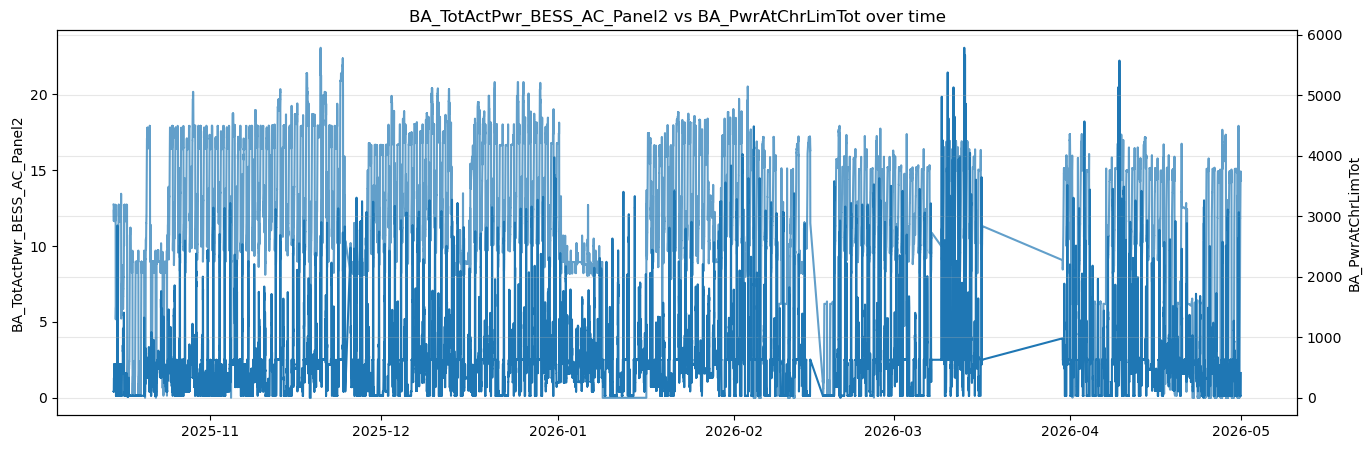

In [58]:
import matplotlib.pyplot as plt

df_plot = df[[target_col, input_col]].dropna().copy()

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(df_plot.index, df_plot[target_col], label=target_col)
ax1.set_ylabel(target_col)

ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot[input_col], label=input_col, alpha=0.7)
ax2.set_ylabel(input_col)

plt.title(f"{target_col} vs {input_col} over time")
plt.grid(True, alpha=0.3)
plt.show()

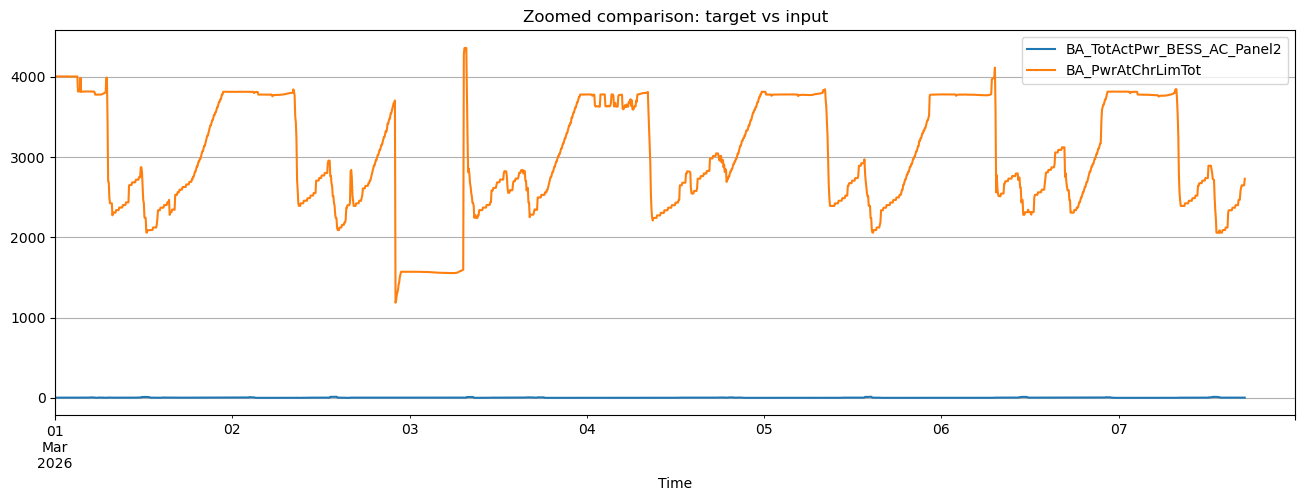

In [59]:
start = "2026-03-01"
end = "2026-03-07"

df_zoom = df.loc[start:end, [
    "BA_TotActPwr_BESS_AC_Panel2",
    "BA_PwrAtChrLimTot"
]]

df_zoom.plot(figsize=(16, 5), grid=True)
plt.title("Zoomed comparison: target vs input")
plt.show()

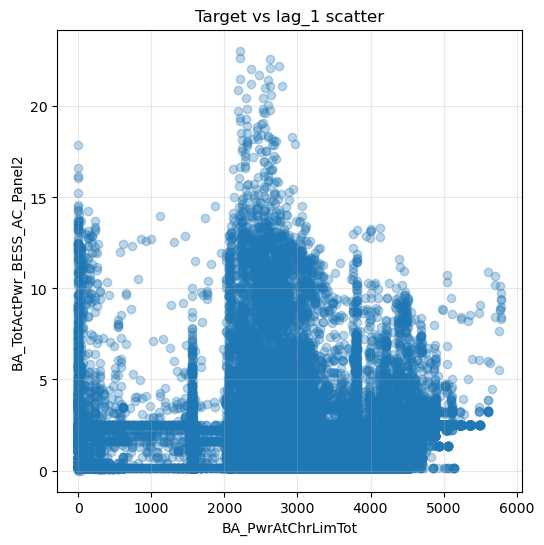

Correlation: -0.08828803750697847


In [60]:
target_col = "BA_TotActPwr_BESS_AC_Panel2"
lag_col = "BA_PwrAtChrLimTot"

df_scatter = df[[target_col, lag_col]].dropna()

plt.figure(figsize=(6, 6))
plt.scatter(df_scatter[lag_col], df_scatter[target_col], alpha=0.3)
plt.xlabel(lag_col)
plt.ylabel(target_col)
plt.title("Target vs lag_1 scatter")
plt.grid(True, alpha=0.3)
plt.show()

print("Correlation:", df_scatter[target_col].corr(df_scatter[lag_col]))

In [61]:
target_col = "BA_TotActPwr_BESS_AC_Panel2"
lag_col = "BA_PwrAtChrLimTot"

active = df[target_col].abs() > 0.5

corr_all = df[[target_col, lag_col]].dropna()[target_col].corr(
    df[[target_col, lag_col]].dropna()[lag_col]
)

corr_active = df.loc[active, [target_col, lag_col]].dropna()[target_col].corr(
    df.loc[active, [target_col, lag_col]].dropna()[lag_col]
)

print("Correlation all data:", corr_all)
print("Correlation active periods only:", corr_active)

Correlation all data: -0.08828803750697847
Correlation active periods only: -0.09683226124565136


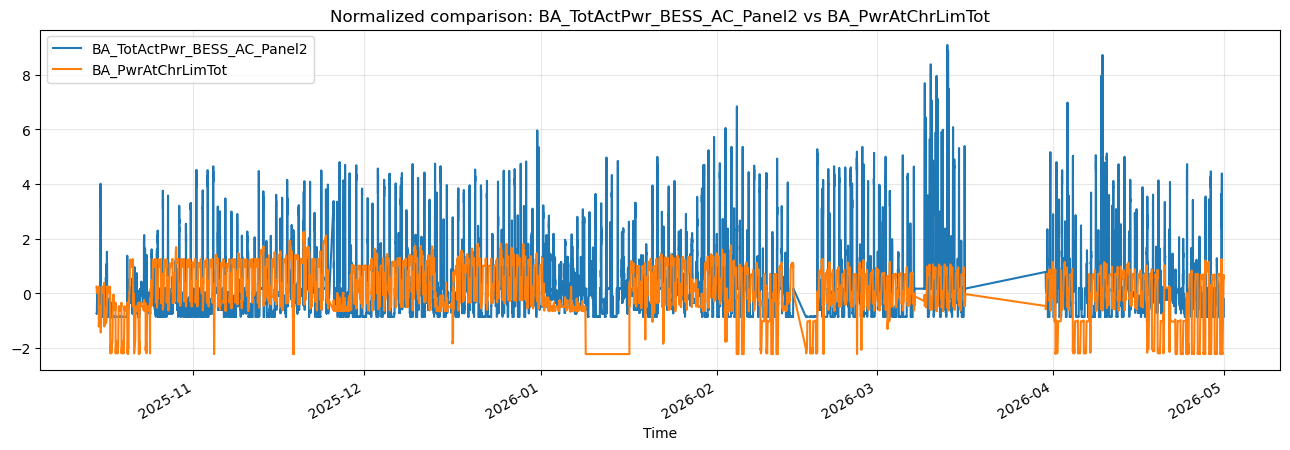

In [62]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

cols = [target_col, input_col]
df_cmp = df[cols].dropna().copy()

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_cmp),
    index=df_cmp.index,
    columns=cols
)

df_scaled.plot(figsize=(16, 5))
plt.title(f"Normalized comparison: {target_col} vs {input_col}")
plt.grid(True, alpha=0.3)
plt.show()

In [63]:
import pandas as pd

max_lag_steps = 96   # 96 steps = 1 day if data is 15-minute resolution
rows = []

for lag in range(0, max_lag_steps + 1):
    corr = df[target_col].corr(df[input_col].shift(lag))
    rows.append({
        "input_signal": input_col,
        "lag_steps": lag,
        "correlation": corr
    })

lag_corr = pd.DataFrame(rows)

lag_corr.sort_values("correlation", key=lambda s: s.abs(), ascending=False).head(10)

,input_signal,lag_steps,correlation
96,BA_PwrAtChrLimTot,96,0.128341
95,BA_PwrAtChrLimTot,95,0.124786
94,BA_PwrAtChrLimTot,94,0.120942
93,BA_PwrAtChrLimTot,93,0.116984
92,BA_PwrAtChrLimTot,92,0.113174
91,BA_PwrAtChrLimTot,91,0.109364
90,BA_PwrAtChrLimTot,90,0.105600
89,BA_PwrAtChrLimTot,89,0.101924
88,BA_PwrAtChrLimTot,88,0.098521
87,BA_PwrAtChrLimTot,87,0.095359


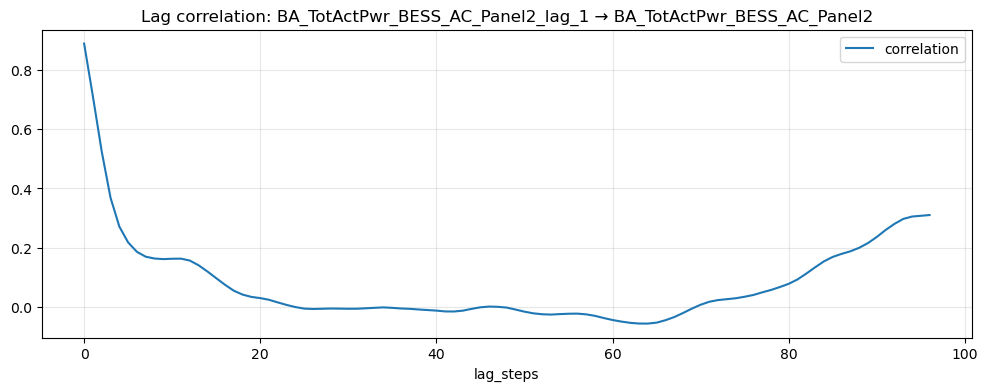

In [22]:
lag_corr.plot(x="lag_steps", y="correlation", figsize=(12, 4))
plt.title(f"Lag correlation: {input_col} → {target_col}")
plt.grid(True, alpha=0.3)
plt.show()